
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_07_abc_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: ABC del aprendizaje de máquina

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

## 1. Entendimiento de los datos

El primer paso consiste en comprender el origen y la naturaleza de los datos. Es fundamental identificar la fuente (por ejemplo, si provienen de un censo, sensores o registros operacionales), así como la unidad de observación, es decir, qué representa cada fila: una persona, un distrito, una vivienda, entre otros.

También es importante reconocer el tipo de variables presentes en el conjunto de datos, distinguiendo entre variables numéricas, categóricas, espaciales o temporales. En esencia, la pregunta clave en esta etapa es: ¿qué representa físicamente cada observación?


## 2. Calidad de datos (Data Quality)

Una vez entendido el dataset, se debe evaluar su calidad. Esto implica analizar la presencia de valores faltantes y determinar si su ausencia es aleatoria o responde a algún patrón estructural. Asimismo, es necesario examinar los valores atípicos (outliers), diferenciando entre posibles errores de medición y fenómenos reales del sistema.

Adicionalmente, se debe verificar la consistencia de los datos, asegurando que las unidades sean correctas y que los valores se encuentren dentro de rangos razonables.


## 3. Análisis exploratorio (EDA)

El análisis exploratorio permite obtener una primera comprensión de la estructura del dataset. En esta fase se estudian las distribuciones de las variables mediante histogramas o funciones de densidad, lo que permite identificar asimetrías, concentraciones o comportamientos anómalos.

También se analizan las relaciones entre variables, por ejemplo, mediante correlaciones o gráficos de dispersión. Finalmente, es útil examinar la geometría del conjunto de datos, identificando posibles agrupaciones (clusters) o patrones espaciales como gradientes.

## 5. Feature Engineering

En esta etapa se transforman las variables originales para construir representaciones más informativas del problema. Esto puede implicar la creación de nuevas variables derivadas o la aplicación de transformaciones que faciliten el modelado.

Por ejemplo, es común definir medidas de densidad como:

$$
\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}
$$

o variables como el número de personas por hogar. También pueden aplicarse transformaciones como el logaritmo de la variable objetivo:

$$
\log(y)
$$


## 6. Partición del dataset

Para evaluar correctamente el desempeño de los modelos, es necesario dividir el conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Esta separación permite evitar el sobreajuste y obtener estimaciones realistas del rendimiento.

Es importante enfatizar que el conjunto de prueba debe permanecer completamente aislado durante el desarrollo del modelo.


## 7. Modelado

En función del problema planteado, se selecciona un modelo adecuado, como regresión lineal, árboles de decisión, métodos de ensamble o redes neuronales. En términos generales, el objetivo es aproximar una relación funcional entre las variables de entrada y la variable objetivo:

$$
y = f_\theta(X)
$$


## 8. Entrenamiento

El entrenamiento consiste en ajustar los parámetros del modelo mediante la minimización de una función de costo. Un ejemplo común en problemas de regresión es el error cuadrático medio:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Este proceso se realiza mediante algoritmos de optimización, como el gradiente descendente.


## 9. Evaluación

Una vez entrenado el modelo, se evalúa su desempeño utilizando métricas adecuadas como el error absoluto medio (MAE), el error cuadrático medio (RMSE) o el coeficiente de determinación (R²):

$$
\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

Es fundamental que esta evaluación se realice sobre datos no utilizados durante el entrenamiento.


## 10. Interpretabilidad

Además del rendimiento, es importante comprender cómo el modelo utiliza las variables. Esto incluye analizar la importancia de las variables y la sensibilidad de las predicciones frente a cambios en las entradas.


## 11. Incertidumbre

Todo modelo presenta cierto grado de incertidumbre, por lo que es necesario cuantificarla. Esto puede hacerse mediante intervalos de confianza, técnicas de remuestreo como bootstrap o analizando la variabilidad de las predicciones.


## 12. Validación del modelo

La validación busca asegurar que el modelo generaliza adecuadamente a nuevos datos. Esto implica evaluar su robustez frente a diferentes particiones o condiciones.



## 14. Comunicación

Los resultados deben presentarse de forma clara y coherente, apoyándose en visualizaciones adecuadas y evitando interpretaciones exageradas. La comunicación es clave para que el análisis tenga impacto.

## 15. Deployment

En contextos aplicados, el modelo puede ser desplegado en producción, por ejemplo, mediante una API o procesos batch. Esto permite su uso en sistemas reales.

## 16. Monitoreo y drift

Una vez en producción, es necesario monitorear el comportamiento del modelo, especialmente posibles cambios en la distribución de los datos:

$$
P_{\text{train}}(X) \neq P_{\text{prod}}(X)
$$

Estos cambios pueden afectar el desempeño del modelo con el tiempo.

## 17. Reproducibilidad

Finalmente, todo el proceso debe ser reproducible. Esto implica mantener un adecuado versionado de los datos, código limpio, control de semillas aleatorias y registro de experimentos.

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

# 1.0 Análisis del data frame

1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

  ```python
  df.info()
  df.describe()
  df.isnull().sum()
  df.isna().sum()
```
Estos dos últimos son equivalentes.

3. ¿Cuántas variables tiene el dataset y de qué tipo son?
4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

5. Determinar los elementos únicos dentro de la columna ocean_proximity.

6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#1) Leer el data frame en formato csv en la dirección

url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"

df = pd.read_csv(url)
info = df.info()
describe = df.describe()
null = df.isnull().sum()
na = df.isna().sum()

print("df.info()")
print(info)
print("--------------------------------------")
print("df.describe()")
print(describe)
print("--------------------------------------")
print("df.isnull().sum()")
print(null)
print("--------------------------------------")
print("df.isna().sum()")
print(na)

# Acción para manejar los valores faltantes en 'total_bedrooms'
# Se utiliza la mediana debido a la distribución sesgada de la variable.
median_total_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"].fillna(median_total_bedrooms, inplace=True)

print("\n--- Después de manejar los valores faltantes en 'total_bedrooms' ---")
print("df.isnull().sum() después de la imputación:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
df.info()
None
--------------------------------------
df.describe()
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861        

/tmp/ipykernel_4406/852338815.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(median_total_bedrooms, inplace=True)


3. ¿Cuántas variables tiene el dataset y de qué tipo son?

R/= El dataset tiene 10 variables, 9 de tipo numérico y 1 de tipo objeto.

4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

R/= Existen valores faltantes, estos están en la columna total_bedrooms, con 207 valores faltantes.

Manejo de valores nulos: Para la columna total_bedrooms, la mejor solución es reemplazar los valores nulos con la mediana. La razón es que, al observar el df.describe(), la media (537.87) es notablemente mayor que la mediana (435.0). Esto sugiere que la distribución de total_bedrooms está sesgada a la derecha o que existen valores atípicos. En estas situaciones, la mediana es una medida de tendencia central más robusta y menos sensible a los valores extremos, lo que evita distorsionar la distribución original de la variable. Eliminar las 207 filas implicaría una pérdida de aproximadamente el 1% de los datos, lo cual es aceptable en algunos casos, pero la imputación con la mediana es una opción más conservadora que preserva el tamaño del dataset y maneja la asimetría de la distribución.

In [18]:
#5. Determinar los elementos únicos dentro de la columna ocean_proximity.

unicos_ocean = df["ocean_proximity"].unique()
print(unicos_ocean)

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

In [19]:
cols = ["housing_median_age",   "total_rooms",  "total_bedrooms",   "population",   "households",   "median_income",    "median_house_value"]
df_group = df.groupby("ocean_proximity")[cols].mean()
print(df_group)

                 housing_median_age  total_rooms  total_bedrooms   population  \
ocean_proximity                                                                 
<1H OCEAN                 29.279225  2628.343586      545.293892  1520.290499   
INLAND                    24.271867  2717.742787      533.051443  1391.046252   
ISLAND                    42.400000  1574.600000      420.400000   668.000000   
NEAR BAY                  37.730131  2493.589520      513.491266  1230.317467   
NEAR OCEAN                29.347254  2583.700903      537.446200  1354.008653   

                 households  median_income  median_house_value  
ocean_proximity                                                 
<1H OCEAN        517.744965       4.230682       240084.285464  
INLAND           477.447565       3.208996       124805.392001  
ISLAND           276.600000       2.744420       380440.000000  
NEAR BAY         488.616157       4.172885       259212.311790  
NEAR OCEAN       501.244545       4.005785

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

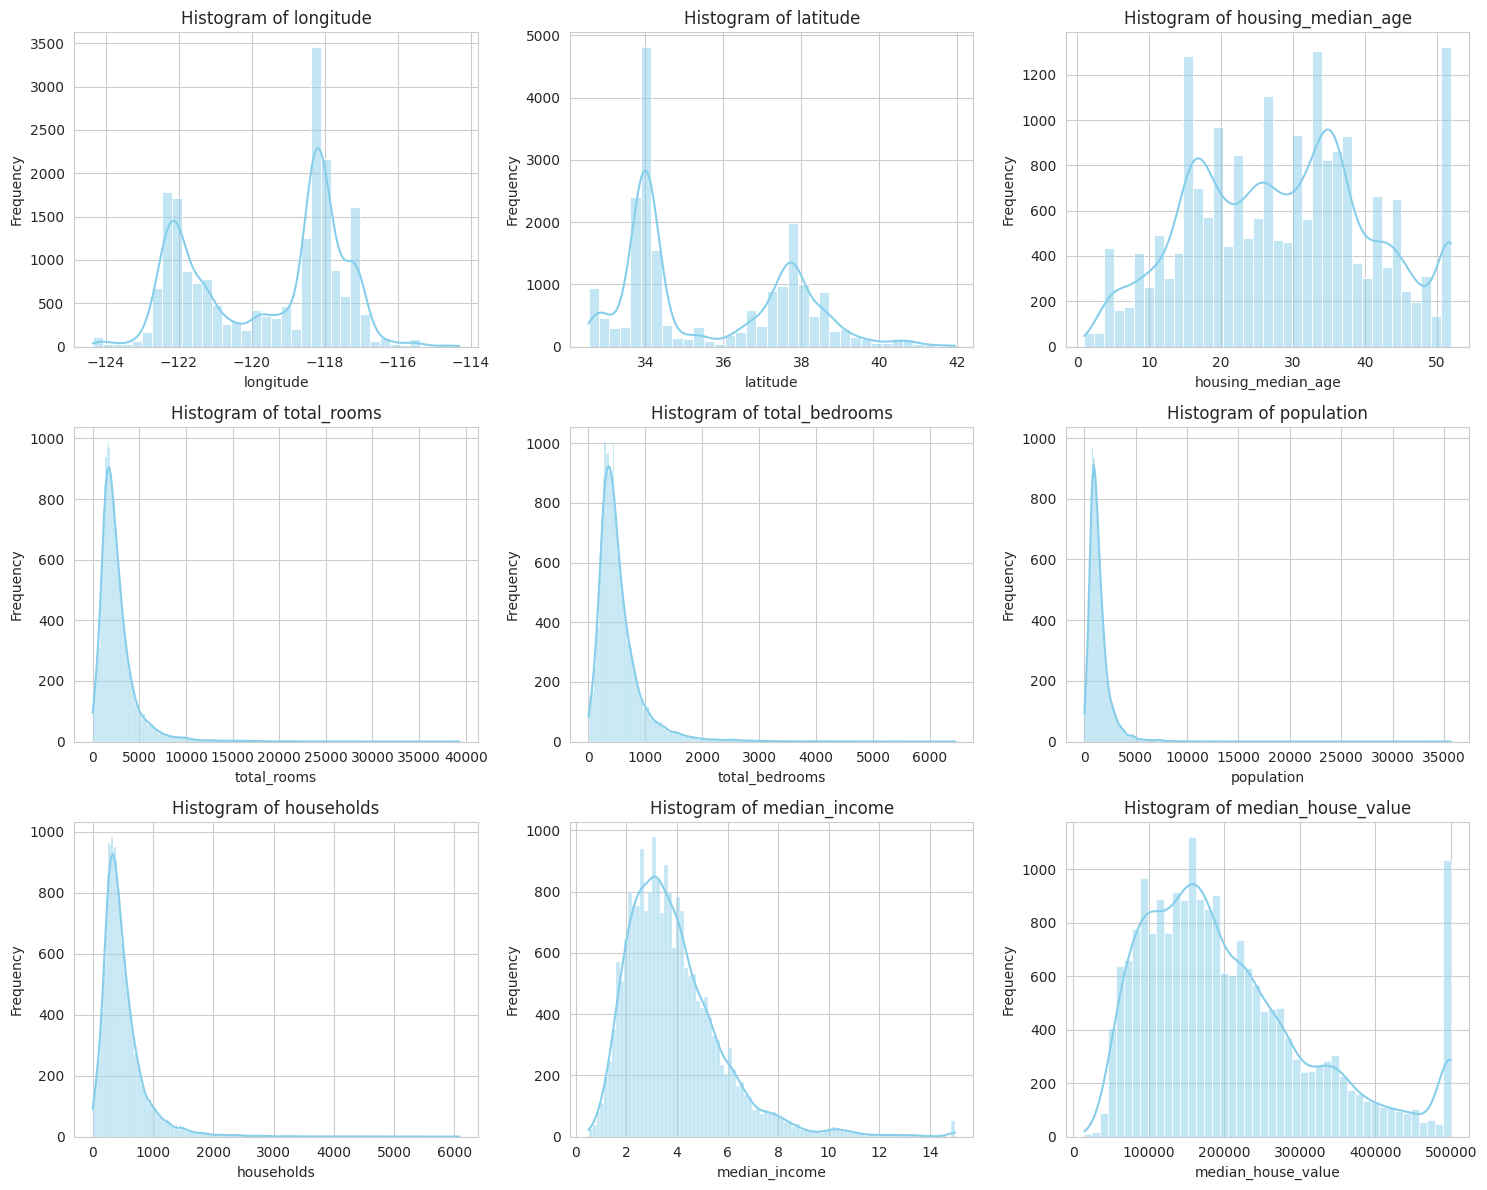

In [20]:
sns.set_style("whitegrid")

# Identify numerical columns (excluding 'ocean_proximity')
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Determine grid size for subplots
num_cols_per_row = 3
num_rows = int(np.ceil(len(numerical_cols) / num_cols_per_row))

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(num_cols_per_row * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot histogram for each numerical column
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### [Diagrama de caja](https://en.wikipedia.org/wiki/Box_plot)


### Diagrama de caja

![box](https://upload.wikimedia.org/wikipedia/commons/e/ed/Box_Plot_Picture.png)



### Interpretación de un diagrama de caja

- Desde el minimo al valor más bajo de la caja: primer cuartil, 25% de los datos
- Desde el valor más bajo de la caja hasta la mediana: segundo cuartil, 25% de los datos
- Desde la mediana hasta el valor mas alto de la caja : tercer cuartil, 25% de los datos
- Desde el valor mas alto de la caja hasta el máximo: Cuarto  cuartil, 25% de los datos


El rango intercuartil $IQR = Q_3-Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:

$Max = Q3 + 1.5IQR$

$Min = Q1 - 1.5IQR$



El cuartil puede ser determinado como sigue:

Para calcular los cuartiles de una lista de números:

- Ordenar los números de menor a mayor.
- Calcular la posición de cada cuartil usando la fórmula: Q = a (N+1) / 4, donde Q es la posición del cuartil, a es el número del cuartil (1, 2 o 3), y N es el número total de datos.
- Si la posición del cuartil es un número entero, el valor del cuartil es el dato que está en esa posición.
- Si la posición del cuartil es un número decimal, el valor del cuartil se interpola usando la fórmula: Q = x + d (y - x), donde Q es el valor del cuartil, x es el dato anterior a la posición del cuartil, y es el dato posterior a la posición del cuartil, y d es la parte decimal de la posición del cuartil.


Veamos un ejemplo:



In [ ]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(len(T))
print(f"T sort:{Tsort}")
len(T)/4

In [ ]:

IQR=9
max_ = 75 + 1.5*IQR
min_ = 66 - 1.5*IQR
print(max_)
print(min_)
plt.boxplot(T)

8. Empleando el siguiente código realiza el gráfico boxplot,
```python
#draw boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()
```

9. Determina la matrix de correlación.

### [Matrix de correlación](https://en.wikipedia.org/wiki/Correlation)

¿Como se determina la matrix de correlación?

![Matrix de correlación](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1920px-Correlation_examples2.svg.png)



```python
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

# 2.0 Preparacion del data frame

## Evitar el data *Snooping bias*.

En algunos casos se sugiere dividir los datos en entrenamiento y test desde el principio dado que el cerebro puede sobreajustar el dataset y los resultados no significativos se pueden volver significativos. El procedimiento correcto es probar cualquier hipótesis en un conjunto de datos que no se utilizó para generar las hipótesis inicial.


## *Sampling bias*

Si el dataset es lo suficientemente grande un muestreo aleatorio de la muestra puede ser considerado, sin embargo si la muestra es pequena se debe garantizar homegeniedad en el dataset de entrenamiento.


Ejemplo:

Por ejemplo, la población de EE. UU. esta compuesto por un 51,3 % de mujeres y un 48,7 % de hombres, por lo que una encuesta bien realizada en EEUU
trata de mantener esta proporción en la muestra: 513 mujeres y 487 hombres. Esto se llama muestreo estratificado(stratified sampling): la población se divide en subgrupos homogéneos llamados estratos(strata), y se muestrea el número correcto de instancias de cada estrato para garantizar que el
El conjunto de prueba es representativo de la población general. Si usaran muestras puramente aleatorias, habría alrededor del 12% de posibilidades de muestrear un conjunto de prueba sesgado con menos del 49% de mujeres o más del 54% de mujeres. De cualquier manera, los resultados de la encuesta serían
significativamente sesgada.


12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```


13. División del dataset en grupos:


La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df["income_cat"].value_counts() / len(df)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
```

13. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```




# Limpieza de datos

Lo que sigue son códigos que pueden servir para limpiar los datos.

```python

df.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()

```

##imputer

Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):


```python
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop("ocean_proximity", axis=1)

imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

imp_mean.statistics_
```

14. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```


# Manejo de texto y atributos categóricos
15.  ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```


# Escalamiento de variables

16. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```


17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

1. ¿que puede concluir respecto al modelo empleado?
2. ¿El modelo de regresión lineal es valido para lo construido,
3. ¿qué informacion nos da el score?
4. ¿Puede ser ajustado a otro modelo?
5. ¿Como puede autmatizar todo el proceso empleando pipelines?




